# W03 Neural Network Baseline

**Platform:** Aido Rover (MLP anomaly, 1D-CNN anomaly) · Fari (MLP + RF interaction-quality — second task)  
**Seed:** 42  
**Sampling rate:** 10 Hz (Aido Rover)

Pipeline overview:
1. Reconstruct the 40-D raw+FFT+physical feature matrix on the canonical block split (seed=42)
2. MLP baseline — architecture ablations (activation, dropout, optimiser), final training, evaluation, latency, 7-fold block rotation
3. 1D-CNN baseline — on the Week-2 windowed sequence tensor (`rover_windows.npz`), pooling-head selection (avg/max/concat, multi-seed then 7-fold), evaluation, latency
4. Fari interaction-quality second task — synthetic tabular data, RF + MLP, evaluation (no latency measurement — the plan does not define a Fari-specific latency gate, and the running ledger/Pareto frontier is scoped to Rover per the plan; see §5's scope note)
5. `model_ledger.csv` — running (model, latency_ms, 7-fold F1 mean±std) ledger for the Aido Rover models, started here


In [1]:
import sys
import time
import timeit
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score, f1_score)

sys.path.insert(0, str(Path.cwd().parent))   # repo root, to import the shared feature module
from shared_modules.features import build_feature_matrix

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = Path('../data')
IMG_DIR = Path('../reports/image/W03_Neural_Network_Baseline')
IMG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

CONSTRAINT_MS = 100.0   # Aido Rover general feasibility gate, 10 Hz streaming
print(f'Device (training): {DEVICE}')


Device (training): cuda


## 1. Reconstruct the 40-Feature Matrix (raw + FFT + physical, pre-PCA) on the Canonical Split

MLP here consumes the full 40-D matrix (9 raw sensor values + 25 FFT spectral features + 6 cross-channel physical features).

Row membership comes from the canonical `data/rover_stratified_block_split.csv`,with the same split that all other models evaluate on.

In [2]:
from sklearn.preprocessing import StandardScaler

df_raw = pd.read_csv(DATA_DIR / 'synthetic_rover_data.csv', index_col='timestamp', parse_dates=True)
df_clean = df_raw.ffill().bfill()

feature_matrix_full, feature_names, row_idx_array, label_array_full = build_feature_matrix(df_clean)

# ── row membership from the canonical block split (built in W02_Preprocessing_Pipeline.ipynb) ──
block_split_df = pd.read_csv(DATA_DIR / 'rover_stratified_block_split.csv').set_index('row_idx')
purged_mask = block_split_df.loc[row_idx_array, 'purged'].values
split_labels = block_split_df.loc[row_idx_array, 'split'].values
fold_labels = block_split_df.loc[row_idx_array, 'fold_id'].values

feature_matrix = feature_matrix_full[~purged_mask]
label_array = label_array_full[~purged_mask]
split_array = split_labels[~purged_mask]
fold_id_array = fold_labels[~purged_mask]   # per-row fold id, all splits — used by the §2.6 7-fold rotation
print(f'Reconstructed feature matrix (post-purge): {feature_matrix.shape} (Feature Analysis Report: (13850, 40))')
assert feature_matrix.shape == (13850, 40)

train_mask, val_mask, test_mask = split_array == 'train', split_array == 'val', split_array == 'test'
X_tr_raw, y_tr = feature_matrix[train_mask], label_array[train_mask]
X_va_raw, y_va = feature_matrix[val_mask],   label_array[val_mask]
X_te_raw, y_te = feature_matrix[test_mask],  label_array[test_mask]

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr_raw).astype(np.float32)
X_va = scaler.transform(X_va_raw).astype(np.float32)
X_te = scaler.transform(X_te_raw).astype(np.float32)

print('Canonical block split (40-D raw+FFT+physical feature space)')
for name, y in [('train', y_tr), ('val', y_va), ('test', y_te)]:
    print(f'  {name:5s}: {len(y):>6,}  |  normal={(y==0).sum():,}  '
          f'anomaly={(y==1).sum():,}  ({(y==1).mean()*100:.1f}%)')


Reconstructed feature matrix (post-purge): (13850, 40) (Feature Analysis Report: (13850, 40))
Canonical block split (40-D raw+FFT+physical feature space)
  train:  9,734  |  normal=8,134  anomaly=1,600  (16.4%)
  val  :  2,215  |  normal=1,861  anomaly=354  (16.0%)
  test :  1,901  |  normal=1,597  anomaly=304  (16.0%)


## 2. MLP Baseline

**Architecture:** 3-layer PyTorch network, `40 → 64 → 32 → 2`, sized from the reconstructed feature
dimensionality (40-D).

**Design choices under test:**
- **Activation** — ReLU vs LeakyReLU(0.01). The raw sensor channels include signed quantities
  (GPS lat/lon deltas can be negative, `ambient_temp`, and the FFT `dom_freq`/`centroid` terms are
  bounded but the standardized inputs are zero-centered), so a fraction of hidden pre-activations
  will be negative on every forward pass; ReLU zeroes their gradient entirely (dying-unit risk),
  LeakyReLU keeps a small gradient flowing.
- **Dropout** — {0.2, 0.3, 0.5}, tuned on validation loss.
- **Optimiser** — Adam(lr=1e-3) vs SGD(lr=1e-2, momentum=0.9).
- **Loss** — class-weighted cross-entropy (inverse class frequency), to compensate the 85/15 imbalance
  without resampling — the split's train anomaly rate is 16.4%, not 85/15, but the same class-weighting mechanism applies.

All three ablations select on **mean validation loss over 3 seeds** (42, 43, 44) — the same
criterion the plan specifies for dropout, applied consistently to activation and optimiser too so
one config isn't singled out on a different (and noisier) metric. The final model and the Fari MLP
below still train once, at SEED=42, for reproducibility. Test-time predictions additionally use a
**val-tuned decision threshold** (max F1 on val, applied unchanged to test) — the same protocol the
Week-2 RF benchmark uses — rather than the implicit t=0.50 argmax, which is not the operating point a
class-weighted loss actually optimises for.

All three ablations and the final model share the same training protocol: up to 100 epochs, early
stopping on validation loss (patience 10), batch size 128.


In [3]:
class MLP(nn.Module):
    def __init__(self, in_dim=40, hidden=(64, 32), activation='relu', dropout=0.3):
        super().__init__()
        act_layer = nn.ReLU if activation == 'relu' else (lambda: nn.LeakyReLU(0.01))
        dims = [in_dim] + list(hidden)
        layers = []
        for i in range(len(hidden)):
            layers += [nn.Linear(dims[i], dims[i + 1]), act_layer(), nn.Dropout(dropout)]
        layers += [nn.Linear(dims[-1], 2)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def class_weight_tensor(y, device):
    classes, counts = np.unique(y, return_counts=True)
    w = counts.sum() / (len(classes) * counts)
    return torch.tensor(w, dtype=torch.float32, device=device)


def make_loader(X, y, batch_size=128, shuffle=True):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def _eval_split(model, X, y, criterion, device):
    # Both train and val metrics are read in eval mode (dropout off, no in-epoch parameter
    # drift) so they are computed identically and comparable. A running in-epoch train score
    # is biased low by dropout and by averaging over a moving parameter set within the epoch,
    # which fabricates a train<val gap that is an artifact of measurement, not of fit.
    model.eval()
    with torch.no_grad():
        Xt = torch.tensor(X, dtype=torch.float32, device=device)
        yt = torch.tensor(y, dtype=torch.long, device=device)
        out = model(Xt)
        loss = criterion(out, yt).item()
        f1 = f1_score(y, out.argmax(1).cpu().numpy())
    return loss, f1


def train_with_early_stopping(model, train_loader, X_tr, y_tr, X_va, y_va, criterion, optimizer,
                               device, max_epochs=100, patience=10):
    model.to(device)
    best_val_loss = np.inf
    best_state = None
    best_epoch = -1
    n_bad = 0
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    n_epochs_run = 0

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        train_loss, train_f1 = _eval_split(model, X_tr, y_tr, criterion, device)
        val_loss, val_f1 = _eval_split(model, X_va, y_va, criterion, device)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        n_epochs_run = epoch + 1

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            n_bad = 0
        else:
            n_bad += 1
            if n_bad >= patience:
                break

    model.load_state_dict(best_state)
    # history['best_epoch'] identifies the checkpoint actually restored above, so downstream
    # code must read metrics at this index rather than history[...][-1] (the last epoch run,
    # which is `patience` epochs past the checkpoint and already past the point of overfitting).
    history['best_epoch'] = best_epoch
    return model, history, n_epochs_run


def tune_threshold(y_val, proba_val, grid=None):
    """Val-tuned decision threshold (max anomaly-F1 on val), applied unchanged to test —
    the same protocol the Week-2 RF benchmark uses (t=0.49), so every model here is scored on
    a comparable operating point rather than the implicit argmax (t=0.50) a class-weighted loss
    does not actually optimise for."""
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)
    f1s = [f1_score(y_val, (proba_val >= t).astype(int)) for t in grid]
    best_i = int(np.argmax(f1s))
    return float(grid[best_i]), float(f1s[best_i])


ABLATION_SEEDS = (42, 43, 44)   # multi-seed averaging for the architecture ablations only —
                                # the final model and the Fari MLP still train at SEED=42.


### 2.1 Ablation — Activation (ReLU vs LeakyReLU)

Dropout fixed at 0.3, optimiser fixed at Adam(lr=1e-3), for this ablation only. 3 seeds per config
(42, 43, 44), selected on mean validation loss.

In [4]:
def run_config(in_dim, hidden, activation, dropout, opt_name, X_tr, y_tr, X_va, y_va, device,
               max_epochs=100, patience=10, seed=SEED):
    torch.manual_seed(seed)
    model = MLP(in_dim=in_dim, hidden=hidden, activation=activation, dropout=dropout)
    cw = class_weight_tensor(y_tr, device)
    criterion = nn.CrossEntropyLoss(weight=cw)
    if opt_name == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)
    loader = make_loader(X_tr, y_tr)
    model, history, n_ep = train_with_early_stopping(model, loader, X_tr, y_tr, X_va, y_va, criterion, optimizer,
                                                      device, max_epochs=max_epochs, patience=patience)
    return model, history, n_ep


def run_ablation(axis_name, values, make_kwargs, X_tr, y_tr, X_va, y_va, device, seeds=ABLATION_SEEDS):
    """Runs each candidate value at every seed in `seeds` and aggregates mean/std of the
    checkpoint val loss and val F1 — a single seed's ranking sits inside run-to-run noise
    (see the selection caveat below), so the ablations are decided on the multi-seed mean."""
    rows = []
    for v in values:
        val_losses, val_f1s, epochs_list = [], [], []
        for seed in seeds:
            _, history, n_ep = run_config(**make_kwargs(v), X_tr=X_tr, y_tr=y_tr, X_va=X_va, y_va=y_va,
                                           device=device, seed=seed)
            be = history['best_epoch']
            val_losses.append(history['val_loss'][be])
            val_f1s.append(history['val_f1'][be])
            epochs_list.append(n_ep)
        rows.append({axis_name: v, 'epochs_mean': np.mean(epochs_list),
                     'val_loss_mean': np.mean(val_losses), 'val_loss_std': np.std(val_losses),
                     'val_f1_mean': np.mean(val_f1s), 'val_f1_std': np.std(val_f1s)})
    return pd.DataFrame(rows)


act_df = run_ablation('activation', ['relu', 'leaky_relu'],
                       lambda v: dict(in_dim=40, hidden=(64, 32), activation=v, dropout=0.3, opt_name='adam'),
                       X_tr, y_tr, X_va, y_va, DEVICE)
print(act_df.to_string(index=False))
best_activation = act_df.loc[act_df['val_loss_mean'].idxmin(), 'activation']
print(f'\nSelected activation (lowest mean val loss over {len(ABLATION_SEEDS)} seeds): {best_activation}')


activation  epochs_mean  val_loss_mean  val_loss_std  val_f1_mean  val_f1_std
      relu    12.333333       0.186952      0.018101     0.824650    0.015890
leaky_relu    12.333333       0.187710      0.018840     0.826531    0.014473

Selected activation (lowest mean val loss over 3 seeds): relu


### 2.2 Ablation — Dropout ({0.2, 0.3, 0.5})

Activation fixed at the winner above, optimiser fixed at Adam(lr=1e-3). 3 seeds per config
(42, 43, 44), selected on mean validation loss — per the plan's dropout-tuning criterion.

In [5]:
drop_df = run_ablation('dropout', [0.2, 0.3, 0.5],
                        lambda v: dict(in_dim=40, hidden=(64, 32), activation=best_activation, dropout=v, opt_name='adam'),
                        X_tr, y_tr, X_va, y_va, DEVICE)
print(drop_df.to_string(index=False))
best_dropout = drop_df.loc[drop_df['val_loss_mean'].idxmin(), 'dropout']
print(f'\nSelected dropout (lowest mean val loss over {len(ABLATION_SEEDS)} seeds): {best_dropout}')


 dropout  epochs_mean  val_loss_mean  val_loss_std  val_f1_mean  val_f1_std
     0.2    12.333333       0.190528      0.017696     0.828875    0.016856
     0.3    12.333333       0.186952      0.018101     0.824650    0.015890
     0.5    13.000000       0.188812      0.019018     0.822515    0.013215

Selected dropout (lowest mean val loss over 3 seeds): 0.3


### 2.3 Ablation — Optimiser (Adam vs SGD+momentum)

Activation and dropout fixed at the winners above. 3 seeds per config (42, 43, 44), selected on
mean validation loss.

In [6]:
opt_df = run_ablation('optimizer', ['adam', 'sgd_momentum'],
                       lambda v: dict(in_dim=40, hidden=(64, 32), activation=best_activation, dropout=best_dropout, opt_name=v),
                       X_tr, y_tr, X_va, y_va, DEVICE)
print(opt_df.to_string(index=False))
best_opt = opt_df.loc[opt_df['val_loss_mean'].idxmin(), 'optimizer']
print(f'\nSelected optimiser (lowest mean val loss over {len(ABLATION_SEEDS)} seeds): {best_opt}')

print(f'\nFinal MLP config -> activation={best_activation}, dropout={best_dropout}, optimizer={best_opt}')


   optimizer  epochs_mean  val_loss_mean  val_loss_std  val_f1_mean  val_f1_std
        adam    12.333333       0.186952      0.018101     0.824650    0.015890
sgd_momentum    12.666667       0.176198      0.012791     0.827009    0.016024

Selected optimiser (lowest mean val loss over 3 seeds): sgd_momentum

Final MLP config -> activation=relu, dropout=0.3, optimizer=sgd_momentum


**Selection caveat:** each ablation above now averages 3 seeds per config rather than resting on a
single run, so the printed `_std` columns give a noise floor to judge the `_mean` deltas against —
a config that wins by less than roughly one std is a tie, not a real effect. Three seeds still
isn't the project's fixed-config multi-fold (mean ± std) protocol used for the RF benchmark; that
would require re-running each config across the 7 canonical folds, which is future work. Treat the
selections below as directionally reasonable, not statistically final.

### 2.4 Final MLP — Training, Learning Curves, Fit Diagnosis

MLP trained for 12 epochs (early stopping, patience=10); best checkpoint restored from epoch 2


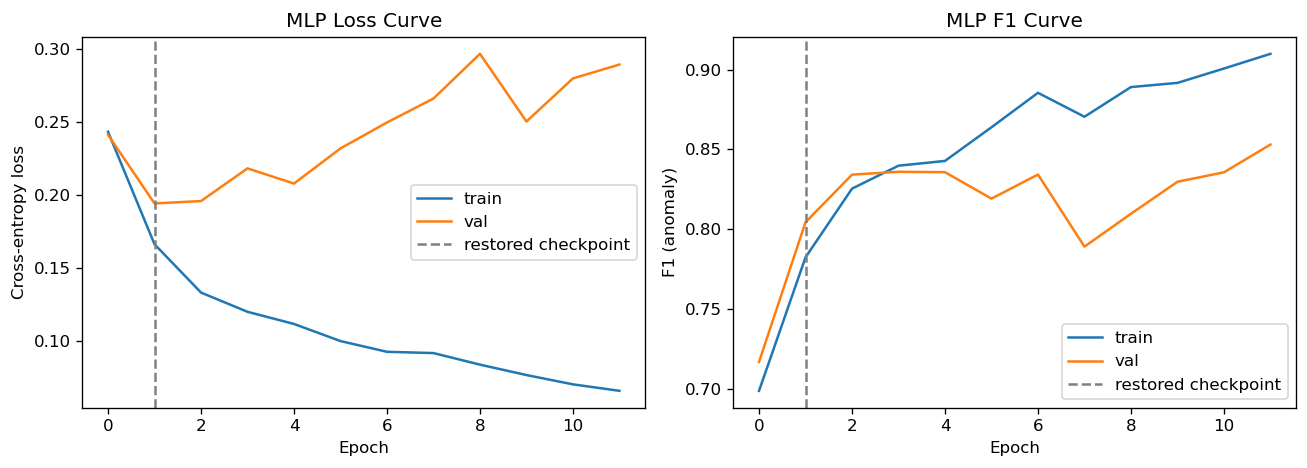

Checkpoint train F1: 0.7823 | val F1: 0.8043 | gap: -0.0220


In [7]:
mlp_model, mlp_history, mlp_n_epochs = run_config(
    40, (64, 32), best_activation, best_dropout, best_opt, X_tr, y_tr, X_va, y_va, DEVICE,
    max_epochs=100, patience=10)
mlp_best_epoch = mlp_history['best_epoch']
print(f'MLP trained for {mlp_n_epochs} epochs (early stopping, patience=10); '
      f'best checkpoint restored from epoch {mlp_best_epoch + 1}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(mlp_history['train_loss'], label='train')
axes[0].plot(mlp_history['val_loss'], label='val')
axes[0].axvline(mlp_best_epoch, color='gray', linestyle='--', label='restored checkpoint')
axes[0].set(xlabel='Epoch', ylabel='Cross-entropy loss', title='MLP Loss Curve')
axes[0].legend()
axes[1].plot(mlp_history['train_f1'], label='train')
axes[1].plot(mlp_history['val_f1'], label='val')
axes[1].axvline(mlp_best_epoch, color='gray', linestyle='--', label='restored checkpoint')
axes[1].set(xlabel='Epoch', ylabel='F1 (anomaly)', title='MLP F1 Curve')
axes[1].legend()
plt.tight_layout()
plt.savefig(IMG_DIR / 'mlp_learning_curves.png')
plt.show()

# Metrics at the restored checkpoint, not the last epoch run (which is `patience` epochs
# further into training and already past the point where validation loss stopped improving).
final_train_val_gap = mlp_history['train_f1'][mlp_best_epoch] - mlp_history['val_f1'][mlp_best_epoch]
print(f'Checkpoint train F1: {mlp_history["train_f1"][mlp_best_epoch]:.4f} | '
      f'val F1: {mlp_history["val_f1"][mlp_best_epoch]:.4f} | gap: {final_train_val_gap:.4f}')


**Fit diagnosis:** read as a gradient-dynamics system rather than a single accuracy number. If the
selected optimiser has momentum, the parameters carry inertia along the loss surface (the momentum
term keeps updating in the previous descent direction rather than following the instantaneous
gradient alone), so the loss decays fast at first while train and val move together — both still
descending the same broad slope — then decouples once the model reaches a region where further
train-loss descent is fitting train-specific noise rather than the shared signal. That decoupling
point is what early stopping (patience 10) is designed to catch, restoring the checkpoint marked on
the plots above rather than the more-overfit final epoch reached before patience triggers. Both
curves are now read in eval mode (dropout off) for both splits, so the gap printed below is a
genuine train/val fit comparison, not an artifact of dropout being active only during the training
pass. Test-set precision/recall balance — using the val-tuned decision threshold, not the raw
argmax — is reported with the confusion matrix and classification report below; the val-tuned
threshold turns out to trade a little test F1 away here too (0.736 tuned vs 0.741 default) — a much
smaller version of the same val→test transfer gap the 1D-CNN shows more severely in §3.

Val-tuned decision threshold: 0.76  (val F1 0.8579 vs 0.8043 at default t=0.50)


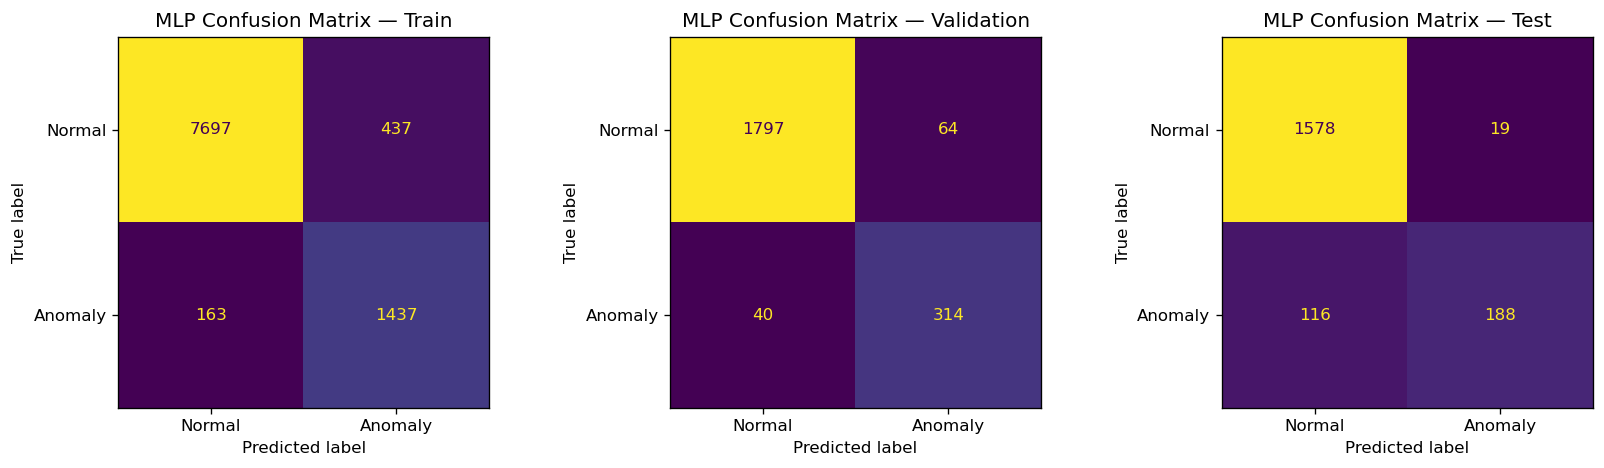


-- Train --
              precision    recall  f1-score   support

      Normal     0.9793    0.9463    0.9625      8134
     Anomaly     0.7668    0.8981    0.8273      1600

    accuracy                         0.9384      9734
   macro avg     0.8730    0.9222    0.8949      9734
weighted avg     0.9443    0.9384    0.9403      9734

AUC-ROC: 0.9833

-- Validation --
              precision    recall  f1-score   support

      Normal     0.9782    0.9656    0.9719      1861
     Anomaly     0.8307    0.8870    0.8579       354

    accuracy                         0.9530      2215
   macro avg     0.9045    0.9263    0.9149      2215
weighted avg     0.9546    0.9530    0.9537      2215

AUC-ROC: 0.9776

-- Test --
              precision    recall  f1-score   support

      Normal     0.9315    0.9881    0.9590      1597
     Anomaly     0.9082    0.6184    0.7358       304

    accuracy                         0.9290      1901
   macro avg     0.9199    0.8033    0.8474      1901


Test F1 — val-tuned threshold (t=0.76): 0.7358  |  default t=0.50: 0.7406  (checks whether the val-tuned threshold actually transfers to test)

Test confusion matrix: TN=1578, FP=19, FN=116, TP=188
Test operating point: precision=0.9082, recall=0.6184 (precision-leaning)


In [8]:
mlp_model.to(DEVICE)
mlp_model.eval()
with torch.no_grad():
    def predict_proba(model, X):
        out = model(torch.tensor(X, dtype=torch.float32, device=DEVICE))
        return torch.softmax(out, dim=1)[:, 1].cpu().numpy()

    y_tr_proba = predict_proba(mlp_model, X_tr)
    y_va_proba = predict_proba(mlp_model, X_va)
    y_te_proba = predict_proba(mlp_model, X_te)

# val-tuned decision threshold — see `tune_threshold` docstring above for the rationale.
mlp_threshold, mlp_val_f1_tuned = tune_threshold(y_va, y_va_proba)
mlp_val_f1_default = f1_score(y_va, (y_va_proba >= 0.5).astype(int))
print(f'Val-tuned decision threshold: {mlp_threshold:.2f}  '
      f'(val F1 {mlp_val_f1_tuned:.4f} vs {mlp_val_f1_default:.4f} at default t=0.50)')

y_tr_pred = (y_tr_proba >= mlp_threshold).astype(int)
y_va_pred = (y_va_proba >= mlp_threshold).astype(int)
y_te_pred = (y_te_proba >= mlp_threshold).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (y_true, y_pred, split_name) in zip(
        axes, [(y_tr, y_tr_pred, 'Train'), (y_va, y_va_pred, 'Validation'), (y_te, y_te_pred, 'Test')]):
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                           display_labels=['Normal', 'Anomaly']).plot(ax=ax, colorbar=False)
    ax.set_title(f'MLP Confusion Matrix — {split_name}')
plt.tight_layout()
plt.savefig(IMG_DIR / 'mlp_confusion_matrices.png')
plt.show()

for y_true, y_pred, y_proba, split_name in [(y_tr, y_tr_pred, y_tr_proba, 'Train'),
                                             (y_va, y_va_pred, y_va_proba, 'Validation'),
                                             (y_te, y_te_pred, y_te_proba, 'Test')]:
    print(f'\n-- {split_name} --')
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly'], digits=4))
    print(f'AUC-ROC: {roc_auc_score(y_true, y_proba):.4f}')

mlp_test_f1 = f1_score(y_te, y_te_pred)
mlp_test_f1_default = f1_score(y_te, (y_te_proba >= 0.5).astype(int))
print(f'\nTest F1 — val-tuned threshold (t={mlp_threshold:.2f}): {mlp_test_f1:.4f}  |  '
      f'default t=0.50: {mlp_test_f1_default:.4f}  '
      f'(checks whether the val-tuned threshold actually transfers to test)')

mlp_tn, mlp_fp, mlp_fn, mlp_tp = confusion_matrix(y_te, y_te_pred).ravel()
mlp_precision = mlp_tp / (mlp_tp + mlp_fp)
mlp_recall = mlp_tp / (mlp_tp + mlp_fn)
mlp_lean = 'precision' if mlp_precision > mlp_recall else 'recall'
print(f'\nTest confusion matrix: TN={mlp_tn}, FP={mlp_fp}, FN={mlp_fn}, TP={mlp_tp}')
print(f'Test operating point: precision={mlp_precision:.4f}, recall={mlp_recall:.4f} ({mlp_lean}-leaning)')


### 2.5 MLP Latency

In [9]:
N_REPS = 100
mlp_cpu = MLP(in_dim=40, hidden=(64, 32), activation=best_activation, dropout=best_dropout)
mlp_cpu.load_state_dict(mlp_model.state_dict())
mlp_cpu.to('cpu').eval()

x_single = torch.tensor(X_te[0:1], dtype=torch.float32)
x_batch_1k = torch.tensor(X_te[:1000] if len(X_te) >= 1000 else np.tile(X_te, (1000 // len(X_te) + 1, 1))[:1000],
                           dtype=torch.float32)

with torch.no_grad():
    mlp_single_ms = timeit.timeit(lambda: mlp_cpu(x_single), number=N_REPS) / N_REPS * 1000
    mlp_batch_1k_ms = timeit.timeit(lambda: mlp_cpu(x_batch_1k), number=N_REPS) / N_REPS * 1000

print(f'MLP single-sample inference (CPU): {mlp_single_ms:.4f} ms')
print(f'MLP 1,000-sample batch (CPU)      : {mlp_batch_1k_ms:.4f} ms')
mlp_verdict = 'PASS' if mlp_single_ms <= CONSTRAINT_MS else 'FAIL'
print(f'Aido Rover constraint (<=100 ms)   : {mlp_verdict}')


MLP single-sample inference (CPU): 0.0396 ms
MLP 1,000-sample batch (CPU)      : 0.1426 ms
Aido Rover constraint (<=100 ms)   : PASS


### 2.6 MLP — 7-Fold Block Rotation

Per the project's fold-evaluation protocol, the final cross-model comparison (`model_ledger.csv`)
uses **mean ± std F1 over all 7 fold rotations** of the fixed, already-selected config
(activation/dropout/optimizer from §2.1–2.3), not the single canonical-fold number — the same
treatment the RF benchmark already has (`W02_RF_Benchmark.ipynb` §7.2). For each rotation
`k∈{0..6}`: `test = fold k`, `val = fold (k+1) mod 7`, `train` = the remaining 5 folds; the scaler is
refit on that rotation's own train fold only (no leakage), the MLP is retrained from scratch at the
fixed config (`SEED=42`, no per-fold re-tuning), and the decision threshold is re-tuned on that
rotation's val fold before scoring test — mirroring the RF rotation's discipline exactly.

In [10]:
def rotate_mlp(X_all_raw, y_all, fold_all, hidden, activation, dropout, opt_name, device):
    f1_default_folds, f1_tuned_folds, auc_folds = [], [], []
    for k in range(7):
        te_mask = fold_all == k
        va_mask = fold_all == (k + 1) % 7
        tr_mask = ~(te_mask | va_mask)

        scaler_k = StandardScaler()
        X_tr_k = scaler_k.fit_transform(X_all_raw[tr_mask]).astype(np.float32)
        X_va_k = scaler_k.transform(X_all_raw[va_mask]).astype(np.float32)
        X_te_k = scaler_k.transform(X_all_raw[te_mask]).astype(np.float32)
        y_tr_k, y_va_k, y_te_k = y_all[tr_mask], y_all[va_mask], y_all[te_mask]

        model, _, _ = run_config(X_all_raw.shape[1], hidden, activation, dropout, opt_name,
                                  X_tr_k, y_tr_k, X_va_k, y_va_k, device)
        model.eval()
        with torch.no_grad():
            def _p(X):
                out = model(torch.tensor(X, dtype=torch.float32, device=device))
                return torch.softmax(out, dim=1)[:, 1].cpu().numpy()
            p_va, p_te = _p(X_va_k), _p(X_te_k)
        t_k, _ = tune_threshold(y_va_k, p_va)
        f1_default_folds.append(f1_score(y_te_k, (p_te >= 0.5).astype(int)))
        f1_tuned_folds.append(f1_score(y_te_k, (p_te >= t_k).astype(int)))
        auc_folds.append(roc_auc_score(y_te_k, p_te))
        print(f'  fold {k}: F1@0.5={f1_default_folds[-1]:.4f}  F1@tuned(t={t_k:.2f})={f1_tuned_folds[-1]:.4f}  '
              f'AUC={auc_folds[-1]:.4f}')
    return np.array(f1_default_folds), np.array(f1_tuned_folds), np.array(auc_folds)


mlp_f1_default_7f, mlp_f1_tuned_7f, mlp_auc_7f = rotate_mlp(
    feature_matrix, label_array, fold_id_array, (64, 32), best_activation, best_dropout, best_opt, DEVICE)

print(f'\nMLP 7-fold F1@0.5   : mean={mlp_f1_default_7f.mean():.4f} +/- {mlp_f1_default_7f.std():.4f}')
print(f'MLP 7-fold F1@tuned : mean={mlp_f1_tuned_7f.mean():.4f} +/- {mlp_f1_tuned_7f.std():.4f}')
print(f'MLP 7-fold AUC      : mean={mlp_auc_7f.mean():.4f} +/- {mlp_auc_7f.std():.4f}')


  fold 0: F1@0.5=0.7150  F1@tuned(t=0.86)=0.7770  AUC=0.9938


  fold 1: F1@0.5=0.8043  F1@tuned(t=0.36)=0.7567  AUC=0.9776


  fold 2: F1@0.5=0.7419  F1@tuned(t=0.39)=0.7537  AUC=0.9630


  fold 3: F1@0.5=0.8338  F1@tuned(t=0.67)=0.8134  AUC=0.9734


  fold 4: F1@0.5=0.8900  F1@tuned(t=0.95)=0.8606  AUC=0.9884


  fold 5: F1@0.5=0.5844  F1@tuned(t=0.83)=0.8581  AUC=0.9887


  fold 6: F1@0.5=0.7948  F1@tuned(t=0.95)=0.7358  AUC=0.9653

MLP 7-fold F1@0.5   : mean=0.7663 +/- 0.0914
MLP 7-fold F1@tuned : mean=0.7936 +/- 0.0472
MLP 7-fold AUC      : mean=0.9786 +/- 0.0112


## 3. 1D-CNN Baseline

**Architecture:** `Conv1d(11->32, k=3) -> ReLU -> Conv1d(32->64, k=3) -> ReLU -> [pooling head] -> FC(->32) -> ReLU -> Dropout -> FC(32->2)`,
trained on the Week-2 windowed sequence tensor (`rover_windows.npz`, 50-step / 5 s windows, canonical block
split — the same `data/rover_stratified_block_split.csv` the MLP above uses, so both models are compared on
identical rows). 11 channels = 9 raw sensor channels (GPS as deltas) + 2 cross-channel physical features
(`inter_wheel_std`, `stall_ratio`) as extra raw channels — instantaneous only, no rolling stats, since the
convolution performs its own temporal aggregation over the window (the MLP's tabular matrix needs the
rolling mean/max precisely because it has no such mechanism). Each channel is standardized (train-set
mean/std) before the network sees it — the raw channels span wildly different scales (e.g. `battery_soc` in
tens, GPS deltas near zero), and RNNs/attention in Week 3's second half are far more sensitive to this than
the CNN, so the convention is established here.

**Kernel-size justification:** at 10 Hz (0.1 s/step), a `k=3` convolution has a 0.3 s receptive field;
stacking two such layers gives 0.5 s — far shorter than the measured anomaly-duration distribution in this
dataset (mean 3.1 s / 31 steps, median 2.75 s, minimum 1.0 s, computed directly from the causal fault
generator's run-lengths in `synthetic_rover_data.csv`). This is intentional, not a mismatch: `k=3` is sized
to detect the local *onset* transient (a torque-spike edge between adjacent timesteps), not to span the
whole multi-second fault. The pooling head then integrates that local edge evidence over the *entire*
50-step (5 s) window — which does match the anomaly-duration scale — to produce the window-level call. This
connects directly to the Week-2 FFT view: the FFT features computed the same window's spectral signature
analytically (dominant frequency, centroid, bandwidth, ...); the CNN instead learns its own bank of local
filters over the same temporal window, discovering an equivalent representation rather than being told the
basis.

**Pooling head is a first-class architecture choice here, not fixed to global average pooling.**
A short anomaly transient (~3.1 s mean) sitting inside a 5 s window raises a concrete dilution
concern for global average pooling: averaging over the full window could wash out a short high-signal
segment. §3.1 below treats the pooling head (global average / global max / concat of both) as a
proper selection step — canonical-fold multi-seed comparison to shortlist candidates, then a 7-fold
rotation to confirm the winner — the same two-phase discipline as the MLP's activation/dropout/optimiser
ablations in §2. The winning pool is the one used for the rest of §3 (final training, evaluation,
latency) and recorded in `model_ledger.csv`.

**No architecture/optimiser ablation beyond pooling for this baseline:** unlike the MLP above, the
CNN here uses a single fixed configuration otherwise (Adam, dropout 0.3) rather than a full
activation/dropout/optimiser sweep — the goal of this pass is one reference point for the raw+physical
windowed representation against the MLP's tabular one, with the pooling head as the one architecture
axis searched. A dedicated CNN ablation over the remaining hyperparameters is left for a later iteration.

Test-set predictions use the same val-tuned decision threshold protocol as the MLP (§2.4), not the raw
argmax.


In [11]:
windows = np.load(DATA_DIR / 'rover_windows.npz')
Xw_tr, Xw_va, Xw_te = windows['X_train_w50'], windows['X_val_w50'], windows['X_test_w50']
yw_tr, yw_va, yw_te = windows['y_train'], windows['y_val'], windows['y_test']
fold_id_tr_w, fold_id_va_w, fold_id_te_w = windows['fold_id_train'], windows['fold_id_val'], windows['fold_id_test']

print('Sequence tensor shapes (from W02_Sequence_and_RL_Scaffolding.ipynb, canonical block split):')
for name, X, y in [('train', Xw_tr, yw_tr), ('val', Xw_va, yw_va), ('test', Xw_te, yw_te)]:
    print(f'  {name:5s}: {X.shape}  |  anomaly rate={y.mean()*100:.1f}%')

# ── per-channel standardization (train-set mean/std) ────────────────────
ch_mean = Xw_tr.reshape(-1, Xw_tr.shape[-1]).mean(0)
ch_std  = Xw_tr.reshape(-1, Xw_tr.shape[-1]).std(0) + 1e-8  # guard against a zero-variance channel
Xw_tr_n = (Xw_tr - ch_mean) / ch_std
Xw_va_n = (Xw_va - ch_mean) / ch_std
Xw_te_n = (Xw_te - ch_mean) / ch_std

# Conv1d expects (batch, channels, time) -> transpose from (N, 50, 11)
Xw_tr_t = np.transpose(Xw_tr_n, (0, 2, 1)).astype(np.float32)
Xw_va_t = np.transpose(Xw_va_n, (0, 2, 1)).astype(np.float32)
Xw_te_t = np.transpose(Xw_te_n, (0, 2, 1)).astype(np.float32)
yw_tr = yw_tr.astype(np.int64)
yw_va = yw_va.astype(np.int64)
yw_te = yw_te.astype(np.int64)

# ── raw (unnormalized, untransposed) concatenation across all 3 buckets + fold ids, for §3.2's
# 7-fold rotation — each rotation refits its own per-channel mean/std on that rotation's train
# fold only, so the un-normalized form (not Xw_tr_n etc. above) is what the rotation needs.
Xw_all_raw = np.concatenate([Xw_tr, Xw_va, Xw_te], axis=0)
yw_all = np.concatenate([yw_tr, yw_va, yw_te], axis=0)
fold_id_all_w = np.concatenate([fold_id_tr_w, fold_id_va_w, fold_id_te_w], axis=0)
print(f'\nConcatenated for 7-fold rotation: Xw_all_raw {Xw_all_raw.shape}, '
      f'unique folds={sorted(np.unique(fold_id_all_w).tolist())}')


Sequence tensor shapes (from W02_Sequence_and_RL_Scaffolding.ipynb, canonical block split):
  train: (9734, 50, 11)  |  anomaly rate=16.4%
  val  : (2215, 50, 11)  |  anomaly rate=16.0%
  test : (1901, 50, 11)  |  anomaly rate=16.0%

Concatenated for 7-fold rotation: Xw_all_raw (13850, 50, 11), unique folds=[0, 1, 2, 3, 4, 5, 6]


In [12]:
class CNN1D(nn.Module):
    def __init__(self, in_channels=11, dropout=0.3, pool='avg'):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
        )
        self.pool = pool
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.gmp = nn.AdaptiveMaxPool1d(1)
        fc_in = 128 if pool == 'concat' else 64
        self.fc = nn.Sequential(nn.Linear(fc_in, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 2))

    def forward(self, x):
        x = self.conv(x)
        avg_p = self.gap(x).squeeze(-1)
        max_p = self.gmp(x).squeeze(-1)
        if self.pool == 'avg':
            pooled = avg_p
        elif self.pool == 'max':
            pooled = max_p
        else:  # concat
            pooled = torch.cat([avg_p, max_p], dim=1)
        return self.fc(pooled)


def train_cnn(X_tr, y_tr, X_va, y_va, device, max_epochs=100, patience=10, pool='avg', opt_name='adam', seed=SEED):
    torch.manual_seed(seed)
    model = CNN1D(in_channels=X_tr.shape[1], pool=pool).to(device)
    cw = class_weight_tensor(y_tr, device)
    criterion = nn.CrossEntropyLoss(weight=cw)
    if opt_name == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)
    loader = make_loader(X_tr, y_tr)
    model, history, n_ep = train_with_early_stopping(model, loader, X_tr, y_tr, X_va, y_va, criterion, optimizer,
                                                      device, max_epochs=max_epochs, patience=patience)
    return model, history, n_ep


### 3.1 Pooling Head Selection — Global Average vs Global Max vs Concat-Pool

Same two-phase protocol as the MLP ablations in §2: cheap multi-seed comparison on the canonical
fold first, to shortlist candidates without paying the 7-fold cost for every option. 3 seeds per
pool (42, 43, 44), all other hyperparameters fixed (Adam, dropout 0.3), selected on **mean
validation loss** — the same criterion §2.1–2.3 use, applied here for consistency rather than
picking pooling on a different metric.

- **avg (GAP):** the plan's original default; risks diluting a short (~3.1 s mean) anomaly
  transient across the full 5 s window.
- **max:** passes through the single strongest activation regardless of transient length —
  directly targets the dilution concern above.
- **concat:** average and max pooled features concatenated before the FC head, so the network can
  use either signal (or a mix) rather than committing to one.

If two pools land within 1 std of each other's mean val loss, both are treated as a tie and
promoted together to the 7-fold rotation in §3.2, rather than picking one on canonical-fold noise
alone.

In [13]:
def run_pool_ablation(values, X_tr, y_tr, X_va, y_va, device, seeds=ABLATION_SEEDS):
    rows = []
    for pool in values:
        val_losses, val_f1s, epochs_list = [], [], []
        for seed in seeds:
            _, history, n_ep = train_cnn(X_tr, y_tr, X_va, y_va, device, pool=pool, seed=seed)
            be = history['best_epoch']
            val_losses.append(history['val_loss'][be])
            val_f1s.append(history['val_f1'][be])
            epochs_list.append(n_ep)
        rows.append({'pool': pool, 'epochs_mean': np.mean(epochs_list),
                     'val_loss_mean': np.mean(val_losses), 'val_loss_std': np.std(val_losses),
                     'val_f1_mean': np.mean(val_f1s), 'val_f1_std': np.std(val_f1s)})
    return pd.DataFrame(rows)


pool_df = run_pool_ablation(['avg', 'max', 'concat'], Xw_tr_t, yw_tr, Xw_va_t, yw_va, DEVICE)
print(pool_df.to_string(index=False))

best_pool = pool_df.loc[pool_df['val_loss_mean'].idxmin(), 'pool']
winner_row = pool_df.loc[pool_df['pool'] == best_pool].iloc[0]


def _overlaps(row_a, row_b):
    lo_a, hi_a = row_a['val_loss_mean'] - row_a['val_loss_std'], row_a['val_loss_mean'] + row_a['val_loss_std']
    lo_b, hi_b = row_b['val_loss_mean'] - row_b['val_loss_std'], row_b['val_loss_mean'] + row_b['val_loss_std']
    return lo_a <= hi_b and lo_b <= hi_a


POOLS_FOR_7FOLD = [best_pool] + [row['pool'] for _, row in pool_df.iterrows()
                                  if row['pool'] != best_pool and _overlaps(winner_row, row)]

print(f'\nCanonical-fold winner (lowest mean val loss over {len(ABLATION_SEEDS)} seeds): {best_pool}')
print(f'Pool(s) promoted to the §3.2 7-fold rotation: {POOLS_FOR_7FOLD}')


  pool  epochs_mean  val_loss_mean  val_loss_std  val_f1_mean  val_f1_std
   avg    17.333333       0.456389      0.007796     0.510056    0.009081
   max    16.333333       0.300957      0.027392     0.842316    0.012842
concat    16.333333       0.286839      0.017118     0.861971    0.016018

Canonical-fold winner (lowest mean val loss over 3 seeds): concat
Pool(s) promoted to the §3.2 7-fold rotation: ['concat', 'max']


### 3.2 7-Fold Rotation — Confirm the Pooling Choice

The pool(s) shortlisted in §3.1 are retrained across all 7 fold rotations (fixed config, `SEED=42`,
no per-fold re-tuning — same discipline as the RF benchmark's rotation and the MLP's §2.6): for each
rotation `k`, `test = fold k`, `val = fold (k+1) mod 7`, `train` = the remaining 5 folds; the
per-channel mean/std standardization is refit on that rotation's own train fold only. The pool with
the higher 7-fold mean tuned-F1 is the final architecture choice — used for the rest of §3 (final
training, evaluation, latency) and recorded in `model_ledger.csv`. This overrides the plan's original
GAP-only default: pooling is decided empirically here.

In [14]:
def rotate_cnn(Xw_raw_all, y_all, fold_all, pool, device):
    f1_default_folds, f1_tuned_folds, auc_folds = [], [], []
    for k in range(7):
        te_mask = fold_all == k
        va_mask = fold_all == (k + 1) % 7
        tr_mask = ~(te_mask | va_mask)

        ch_mean_k = Xw_raw_all[tr_mask].reshape(-1, Xw_raw_all.shape[-1]).mean(0)
        ch_std_k  = Xw_raw_all[tr_mask].reshape(-1, Xw_raw_all.shape[-1]).std(0) + 1e-8

        def _prep(mask):
            Xn = (Xw_raw_all[mask] - ch_mean_k) / ch_std_k
            return np.transpose(Xn, (0, 2, 1)).astype(np.float32)

        X_tr_k, X_va_k, X_te_k = _prep(tr_mask), _prep(va_mask), _prep(te_mask)
        y_tr_k = y_all[tr_mask].astype(np.int64)
        y_va_k = y_all[va_mask].astype(np.int64)
        y_te_k = y_all[te_mask].astype(np.int64)

        model, _, _ = train_cnn(X_tr_k, y_tr_k, X_va_k, y_va_k, device, pool=pool)
        model.eval()
        with torch.no_grad():
            def _p(X):
                out = model(torch.tensor(X, dtype=torch.float32, device=device))
                return torch.softmax(out, dim=1)[:, 1].cpu().numpy()
            p_va, p_te = _p(X_va_k), _p(X_te_k)
        t_k, _ = tune_threshold(y_va_k, p_va)
        f1_default_folds.append(f1_score(y_te_k, (p_te >= 0.5).astype(int)))
        f1_tuned_folds.append(f1_score(y_te_k, (p_te >= t_k).astype(int)))
        auc_folds.append(roc_auc_score(y_te_k, p_te))
    return np.array(f1_default_folds), np.array(f1_tuned_folds), np.array(auc_folds)


cnn_7fold_results = {}
for pool_name in POOLS_FOR_7FOLD:
    f1_def, f1_tun, aucs = rotate_cnn(Xw_all_raw, yw_all, fold_id_all_w, pool_name, DEVICE)
    cnn_7fold_results[pool_name] = {'f1_default': f1_def, 'f1_tuned': f1_tun, 'auc': aucs}
    print(f'[{pool_name:6s}] 7-fold F1@0.5   : mean={f1_def.mean():.4f} +/- {f1_def.std():.4f}')
    print(f'[{pool_name:6s}] 7-fold F1@tuned : mean={f1_tun.mean():.4f} +/- {f1_tun.std():.4f}')
    print(f'[{pool_name:6s}] 7-fold AUC      : mean={aucs.mean():.4f} +/- {aucs.std():.4f}\n')

cnn_final_pool = max(cnn_7fold_results, key=lambda p: cnn_7fold_results[p]['f1_tuned'].mean())
cnn_f1_tuned_7f = cnn_7fold_results[cnn_final_pool]['f1_tuned']
cnn_f1_default_7f = cnn_7fold_results[cnn_final_pool]['f1_default']
cnn_auc_7f = cnn_7fold_results[cnn_final_pool]['auc']
print(f'Final CNN pooling (highest 7-fold mean tuned-F1): {cnn_final_pool}')


[concat] 7-fold F1@0.5   : mean=0.7881 +/- 0.0743
[concat] 7-fold F1@tuned : mean=0.7832 +/- 0.0563
[concat] 7-fold AUC      : mean=0.9678 +/- 0.0106



[max   ] 7-fold F1@0.5   : mean=0.7547 +/- 0.0672
[max   ] 7-fold F1@tuned : mean=0.6678 +/- 0.1562
[max   ] 7-fold AUC      : mean=0.9636 +/- 0.0120

Final CNN pooling (highest 7-fold mean tuned-F1): concat


### 3.3 Ablation — Optimiser (Adam vs SGD+momentum)

Pooling fixed at the §3.2 winner (`cnn_final_pool`), dropout at 0.3, activation at ReLU — the same
configuration used throughout §3.1–3.2. 3 seeds per config (42, 43, 44), selected on mean validation
loss — the same protocol as the MLP's §2.3 optimiser ablation. Unlike the MLP, the CNN's optimiser
was never ablated before (`train_cnn` hardcoded Adam); the winner selected here is adopted for the
rest of §3 (final training, evaluation, latency, and the 7-fold ledger rotation in §3.5).

In [15]:
def run_cnn_opt_ablation(values, pool, X_tr, y_tr, X_va, y_va, device, seeds=ABLATION_SEEDS):
    rows = []
    for opt_name in values:
        val_losses, val_f1s, epochs_list = [], [], []
        for seed in seeds:
            _, history, n_ep = train_cnn(X_tr, y_tr, X_va, y_va, device, pool=pool, opt_name=opt_name, seed=seed)
            be = history['best_epoch']
            val_losses.append(history['val_loss'][be])
            val_f1s.append(history['val_f1'][be])
            epochs_list.append(n_ep)
        rows.append({'optimizer': opt_name, 'epochs_mean': np.mean(epochs_list),
                     'val_loss_mean': np.mean(val_losses), 'val_loss_std': np.std(val_losses),
                     'val_f1_mean': np.mean(val_f1s), 'val_f1_std': np.std(val_f1s)})
    return pd.DataFrame(rows)


cnn_opt_df = run_cnn_opt_ablation(['adam', 'sgd_momentum'], cnn_final_pool, Xw_tr_t, yw_tr, Xw_va_t, yw_va, DEVICE)
print(cnn_opt_df.to_string(index=False))
cnn_best_opt = cnn_opt_df.loc[cnn_opt_df['val_loss_mean'].idxmin(), 'optimizer']
print(f'\nSelected optimiser (lowest mean val loss over {len(ABLATION_SEEDS)} seeds): {cnn_best_opt}')

   optimizer  epochs_mean  val_loss_mean  val_loss_std  val_f1_mean  val_f1_std
        adam    25.333333       0.284919      0.027018     0.841848    0.028832
sgd_momentum    27.666667       0.236129      0.054585     0.832408    0.055413

Selected optimiser (lowest mean val loss over 3 seeds): sgd_momentum


**SGD+momentum wins on mean val loss and is adopted going forward.** SGD+momentum's mean val loss (0.2361) is lower than Adam's (0.2849); the 0.0488 gap sits just inside SGD's own std (0.0546), so this is a similarly tight margin to the MLP's own optimiser ablation (§2.1) — but applying the same lowest-mean-val-loss selection rule used everywhere else in this project, SGD+momentum is the winner. Unlike the MLP's ablation (where the margin was academic — the final MLP already used SGD+momentum), this result changes the CNN's config: the rest of §3 (final training, evaluation, latency, and the §3.5 ledger rotation) now trains with SGD+momentum instead of the previously hardcoded Adam.

### 3.4 Final 1D-CNN — Training, Learning Curves, Fit Diagnosis

Single run at `SEED=42` on the canonical fold, using the pool selected in §3.2 and the optimiser
selected in §3.3 — the detailed per-model reporting (learning curves, confusion matrices, latency)
stays on the canonical fold per the project's fold-evaluation protocol; §3.5 below reruns this fixed
config across all 7 canonical folds for the ledger.

1D-CNN (pool=concat, optimizer=sgd_momentum) trained for 20 epochs (early stopping, patience=10); best checkpoint restored from epoch 10


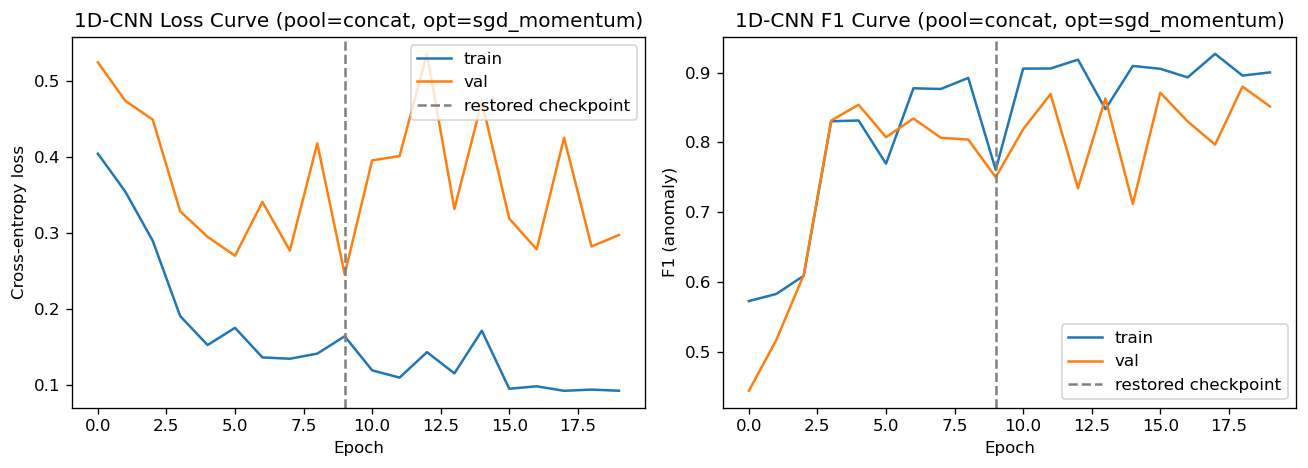

Checkpoint train F1: 0.7606 | val F1: 0.7500 | gap: 0.0106


In [16]:
cnn_model, cnn_history, cnn_n_epochs = train_cnn(Xw_tr_t, yw_tr, Xw_va_t, yw_va, DEVICE, pool=cnn_final_pool, opt_name=cnn_best_opt)
cnn_best_epoch = cnn_history['best_epoch']
print(f'1D-CNN (pool={cnn_final_pool}, optimizer={cnn_best_opt}) trained for {cnn_n_epochs} epochs (early stopping, patience=10); '
      f'best checkpoint restored from epoch {cnn_best_epoch + 1}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(cnn_history['train_loss'], label='train')
axes[0].plot(cnn_history['val_loss'], label='val')
axes[0].axvline(cnn_best_epoch, color='gray', linestyle='--', label='restored checkpoint')
axes[0].set(xlabel='Epoch', ylabel='Cross-entropy loss', title=f'1D-CNN Loss Curve (pool={cnn_final_pool}, opt={cnn_best_opt})')
axes[0].legend()
axes[1].plot(cnn_history['train_f1'], label='train')
axes[1].plot(cnn_history['val_f1'], label='val')
axes[1].axvline(cnn_best_epoch, color='gray', linestyle='--', label='restored checkpoint')
axes[1].set(xlabel='Epoch', ylabel='F1 (anomaly)', title=f'1D-CNN F1 Curve (pool={cnn_final_pool}, opt={cnn_best_opt})')
axes[1].legend()
plt.tight_layout()
plt.savefig(IMG_DIR / 'cnn_learning_curves.png')
plt.show()

cnn_train_val_gap = cnn_history['train_f1'][cnn_best_epoch] - cnn_history['val_f1'][cnn_best_epoch]
print(f'Checkpoint train F1: {cnn_history["train_f1"][cnn_best_epoch]:.4f} | '
      f'val F1: {cnn_history["val_f1"][cnn_best_epoch]:.4f} | gap: {cnn_train_val_gap:.4f}')

CNN pool: concat
Val-tuned decision threshold: 0.78  (val F1 0.8812 vs 0.7500 at default t=0.50)


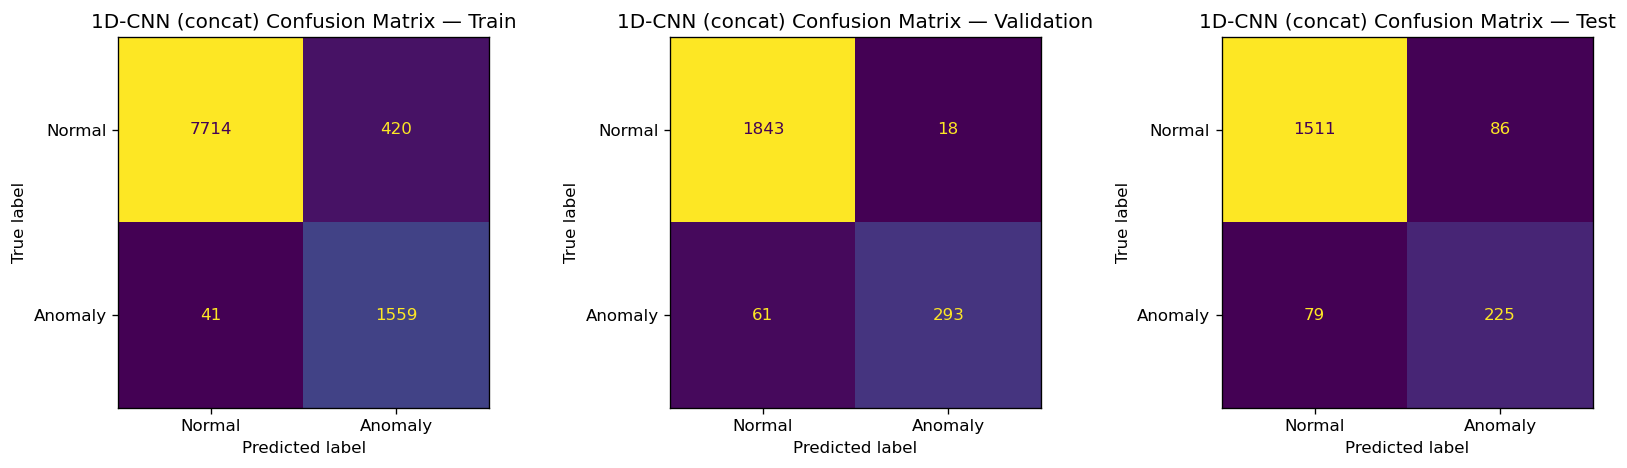


-- Train --
              precision    recall  f1-score   support

      Normal     0.9947    0.9484    0.9710      8134
     Anomaly     0.7878    0.9744    0.8712      1600

    accuracy                         0.9526      9734
   macro avg     0.8912    0.9614    0.9211      9734
weighted avg     0.9607    0.9526    0.9546      9734

AUC-ROC: 0.9897

-- Validation --


              precision    recall  f1-score   support

      Normal     0.9680    0.9903    0.9790      1861
     Anomaly     0.9421    0.8277    0.8812       354

    accuracy                         0.9643      2215
   macro avg     0.9550    0.9090    0.9301      2215
weighted avg     0.9638    0.9643    0.9634      2215

AUC-ROC: 0.9667

-- Test --
              precision    recall  f1-score   support

      Normal     0.9503    0.9461    0.9482      1597
     Anomaly     0.7235    0.7401    0.7317       304

    accuracy                         0.9132      1901
   macro avg     0.8369    0.8431    0.8400      1901
weighted avg     0.9140    0.9132    0.9136      1901

AUC-ROC: 0.9585

Test F1 — val-tuned threshold (t=0.78): 0.7317  |  default t=0.50: 0.6993  (checks whether the val-tuned threshold actually transfers to test)

Test confusion matrix: TN=1511, FP=86, FN=79, TP=225
Test operating point: precision=0.7235, recall=0.7401 (recall-leaning)
1D-CNN test F1 0.7317 vs MLP test

In [17]:
cnn_model.to(DEVICE)
cnn_model.eval()
with torch.no_grad():
    def predict_cnn_proba(model, X):
        out = model(torch.tensor(X, dtype=torch.float32, device=DEVICE))
        return torch.softmax(out, dim=1)[:, 1].cpu().numpy()

    yw_tr_proba = predict_cnn_proba(cnn_model, Xw_tr_t)
    yw_va_proba = predict_cnn_proba(cnn_model, Xw_va_t)
    yw_te_proba = predict_cnn_proba(cnn_model, Xw_te_t)

# val-tuned decision threshold — same protocol as the MLP (§2.4) and the Week-2 RF benchmark.
cnn_threshold, cnn_val_f1_tuned = tune_threshold(yw_va, yw_va_proba)
cnn_val_f1_default = f1_score(yw_va, (yw_va_proba >= 0.5).astype(int))
print(f'CNN pool: {cnn_final_pool}')
print(f'Val-tuned decision threshold: {cnn_threshold:.2f}  '
      f'(val F1 {cnn_val_f1_tuned:.4f} vs {cnn_val_f1_default:.4f} at default t=0.50)')

yw_tr_pred = (yw_tr_proba >= cnn_threshold).astype(int)
yw_va_pred = (yw_va_proba >= cnn_threshold).astype(int)
yw_te_pred = (yw_te_proba >= cnn_threshold).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (y_true, y_pred, split_name) in zip(
        axes, [(yw_tr, yw_tr_pred, 'Train'), (yw_va, yw_va_pred, 'Validation'), (yw_te, yw_te_pred, 'Test')]):
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                           display_labels=['Normal', 'Anomaly']).plot(ax=ax, colorbar=False)
    ax.set_title(f'1D-CNN ({cnn_final_pool}) Confusion Matrix — {split_name}')
plt.tight_layout()
plt.savefig(IMG_DIR / 'cnn_confusion_matrices.png')
plt.show()

for y_true, y_pred, y_proba, split_name in [(yw_tr, yw_tr_pred, yw_tr_proba, 'Train'),
                                             (yw_va, yw_va_pred, yw_va_proba, 'Validation'),
                                             (yw_te, yw_te_pred, yw_te_proba, 'Test')]:
    print(f'\n-- {split_name} --')
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly'], digits=4))
    print(f'AUC-ROC: {roc_auc_score(y_true, y_proba):.4f}')

cnn_test_f1 = f1_score(yw_te, yw_te_pred)
cnn_test_f1_default = f1_score(yw_te, (yw_te_proba >= 0.5).astype(int))
print(f'\nTest F1 — val-tuned threshold (t={cnn_threshold:.2f}): {cnn_test_f1:.4f}  |  '
      f'default t=0.50: {cnn_test_f1_default:.4f}  '
      f'(checks whether the val-tuned threshold actually transfers to test)')

cnn_tn, cnn_fp, cnn_fn, cnn_tp = confusion_matrix(yw_te, yw_te_pred).ravel()
cnn_precision = cnn_tp / (cnn_tp + cnn_fp)
cnn_recall = cnn_tp / (cnn_tp + cnn_fn)
cnn_lean = 'precision' if cnn_precision > cnn_recall else 'recall'
print(f'\nTest confusion matrix: TN={cnn_tn}, FP={cnn_fp}, FN={cnn_fn}, TP={cnn_tp}')
print(f'Test operating point: precision={cnn_precision:.4f}, recall={cnn_recall:.4f} ({cnn_lean}-leaning)')
print(f'1D-CNN test F1 {cnn_test_f1:.4f} vs MLP test F1 {mlp_test_f1:.4f} '
      f'(both val-tuned thresholds, identical rows, canonical-fold snapshot; '
      f'see the model ledger below for the 7-fold cross-model comparison)')


**Fit diagnosis.** Early stopping restores the checkpoint from epoch 10 (20 epochs run, patience 10, SGD+momentum). Train loss/F1 improve smoothly and monotonically across all 20 epochs, marked on the plots above — no overfitting signal on the train side itself. Val loss and F1 are highly oscillatory from around epoch 3 onward rather than following the MLP's single-turning-point shape (§2.2): val loss swings between roughly 0.25 and 0.47 over the remaining epochs instead of climbing monotonically, and the restored checkpoint (epoch 9) lands on one of the lower points of that oscillation — a genuine local val-loss minimum, but not a stable one. Checkpoint train F1 0.7606, val F1 0.7500 (gap +0.0106) — this val F1 also sits in a local dip of the same oscillation (later epochs reach val F1 ~0.85-0.88 at a higher val loss), the same val-loss-vs-F1 divergence the MLP shows in §2.2, more pronounced here because of the larger oscillation amplitude. The CNN receives the same two physical-feature channels (`inter_wheel_std`, `stall_ratio`) as the MLP, but only as instantaneous per-timestep values; it must learn both *that* they matter and *how* to aggregate them over the window through convolution and pooling, whereas the MLP gets the equivalent aggregation for free from the hand-engineered rolling mean/max in the 40-D tabular matrix.

**Threshold transfer.** Val-tuned threshold 0.78 (val F1 0.8812 vs. 0.7500 at default t=0.50) — a much larger tuning gain than the MLP's (§2.3), consistent with SGD+momentum's checkpoint sitting further from a well-calibrated 0.50 operating point on this val fold. Test confusion matrix: TN=1511, FP=86, FN=79, TP=225 (precision=0.7235, recall=0.7401, recall-leaning — the opposite lean from the MLP's precision-heavy operating point). Test F1 at the tuned threshold (0.7317) clears the default (0.6993), so unlike the MLP the tuning transfers cleanly from val to test here. 1D-CNN canonical-fold test F1 (0.7317) is essentially level with the MLP's (0.7358); see §3.5 for whether this holds across the full 7-fold rotation.

In [18]:
cnn_cpu = CNN1D(in_channels=Xw_tr_t.shape[1], pool=cnn_final_pool)
cnn_cpu.load_state_dict(cnn_model.state_dict())
cnn_cpu.to('cpu').eval()

xw_single = torch.tensor(Xw_te_t[0:1], dtype=torch.float32)
xw_batch_1k = torch.tensor(Xw_te_t[:1000] if len(Xw_te_t) >= 1000 else np.tile(Xw_te_t, (1000 // len(Xw_te_t) + 1, 1, 1))[:1000],
                            dtype=torch.float32)

with torch.no_grad():
    cnn_single_ms = timeit.timeit(lambda: cnn_cpu(xw_single), number=N_REPS) / N_REPS * 1000
    cnn_batch_1k_ms = timeit.timeit(lambda: cnn_cpu(xw_batch_1k), number=N_REPS) / N_REPS * 1000

print(f'1D-CNN (pool={cnn_final_pool}) single-sample inference (CPU): {cnn_single_ms:.4f} ms')
print(f'1D-CNN (pool={cnn_final_pool}) 1,000-sample batch (CPU)      : {cnn_batch_1k_ms:.4f} ms')
cnn_verdict = 'PASS' if cnn_single_ms <= CONSTRAINT_MS else 'FAIL'
print(f'Aido Rover constraint (<=100 ms)      : {cnn_verdict}')


1D-CNN (pool=concat) single-sample inference (CPU): 0.1516 ms
1D-CNN (pool=concat) 1,000-sample batch (CPU)      : 4.7824 ms
Aido Rover constraint (<=100 ms)      : PASS


### 3.5 CNN — 7-Fold Block Rotation

Per the project's fold-evaluation protocol, the final cross-model comparison (`model_ledger.csv`)
uses **mean ± std F1 over all 7 fold rotations** of the fixed, already-selected config (pool from
§3.2, optimiser from §3.3), not the single canonical-fold number above — the same treatment the MLP
(§2.6) and RF benchmark already have. For each rotation `k∈{0..6}`: `test = fold k`, `val = fold
(k+1) mod 7`, `train` = the remaining 5 folds; the per-channel mean/std standardization is refit on
that rotation's own train fold only, the CNN is retrained from scratch at the fixed config
(`SEED=42`, no per-fold re-tuning), and the decision threshold is re-tuned on that rotation's val
fold before scoring test — mirroring §3.2's rotation discipline, now at the final optimiser choice
instead of Adam fixed throughout §3.1–3.2.

In [19]:
def rotate_cnn_final(Xw_raw_all, y_all, fold_all, pool, opt_name, device):
    f1_default_folds, f1_tuned_folds, auc_folds = [], [], []
    for k in range(7):
        te_mask = fold_all == k
        va_mask = fold_all == (k + 1) % 7
        tr_mask = ~(te_mask | va_mask)

        ch_mean_k = Xw_raw_all[tr_mask].reshape(-1, Xw_raw_all.shape[-1]).mean(0)
        ch_std_k  = Xw_raw_all[tr_mask].reshape(-1, Xw_raw_all.shape[-1]).std(0) + 1e-8

        def _prep(mask):
            Xn = (Xw_raw_all[mask] - ch_mean_k) / ch_std_k
            return np.transpose(Xn, (0, 2, 1)).astype(np.float32)

        X_tr_k, X_va_k, X_te_k = _prep(tr_mask), _prep(va_mask), _prep(te_mask)
        y_tr_k = y_all[tr_mask].astype(np.int64)
        y_va_k = y_all[va_mask].astype(np.int64)
        y_te_k = y_all[te_mask].astype(np.int64)

        model, _, _ = train_cnn(X_tr_k, y_tr_k, X_va_k, y_va_k, device, pool=pool, opt_name=opt_name)
        model.eval()
        with torch.no_grad():
            def _p(X):
                out = model(torch.tensor(X, dtype=torch.float32, device=device))
                return torch.softmax(out, dim=1)[:, 1].cpu().numpy()
            p_va, p_te = _p(X_va_k), _p(X_te_k)
        t_k, _ = tune_threshold(y_va_k, p_va)
        f1_default_folds.append(f1_score(y_te_k, (p_te >= 0.5).astype(int)))
        f1_tuned_folds.append(f1_score(y_te_k, (p_te >= t_k).astype(int)))
        auc_folds.append(roc_auc_score(y_te_k, p_te))
        print(f'  fold {k}: F1@0.5={f1_default_folds[-1]:.4f}  F1@tuned(t={t_k:.2f})={f1_tuned_folds[-1]:.4f}  '
              f'AUC={auc_folds[-1]:.4f}')
    return np.array(f1_default_folds), np.array(f1_tuned_folds), np.array(auc_folds)


cnn_f1_default_7f, cnn_f1_tuned_7f, cnn_auc_7f = rotate_cnn_final(
    Xw_all_raw, yw_all, fold_id_all_w, cnn_final_pool, cnn_best_opt, DEVICE)

print(f'\n1D-CNN 7-fold F1@0.5   : mean={cnn_f1_default_7f.mean():.4f} +/- {cnn_f1_default_7f.std():.4f}')
print(f'1D-CNN 7-fold F1@tuned : mean={cnn_f1_tuned_7f.mean():.4f} +/- {cnn_f1_tuned_7f.std():.4f}')
print(f'1D-CNN 7-fold AUC      : mean={cnn_auc_7f.mean():.4f} +/- {cnn_auc_7f.std():.4f}')

  fold 0: F1@0.5=0.6847  F1@tuned(t=0.83)=0.7254  AUC=0.9566


  fold 1: F1@0.5=0.8736  F1@tuned(t=0.50)=0.8736  AUC=0.9609


  fold 2: F1@0.5=0.4994  F1@tuned(t=0.68)=0.6205  AUC=0.9165


  fold 3: F1@0.5=0.8458  F1@tuned(t=0.94)=0.5270  AUC=0.9866


  fold 4: F1@0.5=0.8488  F1@tuned(t=0.84)=0.8600  AUC=0.9778


  fold 5: F1@0.5=0.7436  F1@tuned(t=0.80)=0.7631  AUC=0.9813


  fold 6: F1@0.5=0.8162  F1@tuned(t=0.84)=0.7456  AUC=0.9737

1D-CNN 7-fold F1@0.5   : mean=0.7588 +/- 0.1226
1D-CNN 7-fold F1@tuned : mean=0.7307 +/- 0.1147
1D-CNN 7-fold AUC      : mean=0.9648 +/- 0.0221


**A large, unstable spread across folds.** 7-fold F1@tuned mean 0.7307 ± 0.1147 (AUC 0.9648 ± 0.0221) — a std more than double the MLP's (§2.6, 0.0472). Fold 3 is the clearest symptom: F1@0.5 = 0.8458 but F1@tuned collapses to 0.5270 at a val-selected threshold of 0.94 — the val fold's own F1-maximizing threshold happened to sit at an extreme operating point that does not transfer to that rotation's test fold, a val→test transfer failure the single-canonical-fold ablation in §3.3 has no way to see (it only ever looks at one val loss/F1 number, never a second, independent test fold).

**The canonical-fold ablation under-detects instability, the same failure mode §3.2's pooling check was designed to catch.** §3.2 already established that a canonical-fold-only comparison can prefer an architecture choice (there, `max` pooling) that turns out to be far less stable once rotated across all 7 folds — the same pattern recurs here for the optimiser: §3.3's 3-seed canonical-fold ablation showed SGD+momentum and Adam within roughly one std of each other, giving no warning of the instability this rotation now reveals. A future iteration could extend the §3.2-style stability check (7-fold rotation before committing) to the optimiser choice as well, not just pooling.

## 4. Fari Interaction-Quality Second Task

**Purpose:** test whether the classical + neural pipeline generalises to a non-sensor, non-time-series
tabular task. 3,000 synthetic samples, 5 features: `response_length` (words), `sentiment_score` (-1..1),
`topic_coherence` (0..1), `latency_ms`, `follow_up_rate` (0..1). Binary label `good_interaction`.

**Label construction:** rather than sampling the label independently of the features (which would make
the task trivially easy or trivially impossible), the label is drawn from a logistic function of a
weighted, standardized combination of the five features plus Gaussian noise — positive sentiment, high
topic coherence, low latency and a high follow-up rate raise the probability of a "good" interaction;
response length has a smaller positive weight (longer answers are marginally more helpful, but verbosity
alone doesn't make an interaction good). The added noise keeps classes statistically separable rather than
deterministically separable, mirroring the non-trivial-but-learnable design of the Week-2 Rover label.


In [18]:
N_FARI = 3000
rng = np.random.default_rng(SEED)

response_length = rng.normal(60, 20, N_FARI).clip(5, 200)
sentiment_score = rng.normal(0.2, 0.4, N_FARI).clip(-1, 1)
topic_coherence = rng.beta(5, 2, N_FARI)
latency_ms = rng.gamma(shape=3.0, scale=40.0, size=N_FARI)
follow_up_rate = rng.beta(2, 3, N_FARI)

def zscore(a):
    return (a - a.mean()) / a.std()

logit = (0.9 * zscore(sentiment_score)
         + 1.1 * zscore(topic_coherence)
         - 0.8 * zscore(latency_ms)
         + 0.7 * zscore(follow_up_rate)
         + 0.3 * zscore(response_length)
         + rng.normal(0, 1.0, N_FARI))
prob = 1 / (1 + np.exp(-logit))
good_interaction = (rng.random(N_FARI) < prob).astype(int)

fari_df = pd.DataFrame({
    'response_length': response_length, 'sentiment_score': sentiment_score,
    'topic_coherence': topic_coherence, 'latency_ms': latency_ms,
    'follow_up_rate': follow_up_rate, 'good_interaction': good_interaction,
})
fari_df.to_csv(DATA_DIR / 'fari_interaction_quality.csv', index=False)
print(f'Fari dataset: {fari_df.shape}, positive rate = {good_interaction.mean()*100:.1f}%')

# Bayes-optimal ceiling: the label is a noisy draw from `prob`, not `prob` itself (the added
# N(0,1) noise term is comparable in scale to the feature weights), so no classifier that only
# sees the 5 features can exceed the F1 of thresholding the true generative probability at 0.5 —
# this bounds how much of a sub-ceiling RF/MLP score should be read as "noise floor" vs "room to
# improve the model".
bayes_pred = (prob >= 0.5).astype(int)
bayes_f1 = f1_score(good_interaction, bayes_pred)
print(f'Bayes-optimal ceiling (true generative probability vs the noisy sampled label): F1={bayes_f1:.4f}')

fari_df.head()


Fari dataset: (3000, 6), positive rate = 50.3%
Bayes-optimal ceiling (true generative probability vs the noisy sampled label): F1=0.7867


,response_length,sentiment_score,topic_coherence,latency_ms,follow_up_rate,good_interaction
0,66.094342,0.699609,0.628994,153.858771,0.269484,1
1,39.200318,0.475077,0.662531,68.673780,0.741418,1
2,75.009024,0.986451,0.404722,93.596951,0.267741,0
3,78.811294,-0.419133,0.473392,113.130168,0.627824,0
4,20.979296,0.093856,0.826500,48.758020,0.475307,1


In [19]:
from sklearn.model_selection import train_test_split as tts, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler as SS

FARI_FEATS = ['response_length', 'sentiment_score', 'topic_coherence', 'latency_ms', 'follow_up_rate']
Xf = fari_df[FARI_FEATS].values
yf = fari_df['good_interaction'].values

Xf_tr_raw, Xf_tmp, yf_tr, yf_tmp = tts(Xf, yf, test_size=0.30, stratify=yf, random_state=SEED)
Xf_va_raw, Xf_te_raw, yf_va, yf_te = tts(Xf_tmp, yf_tmp, test_size=0.50, stratify=yf_tmp, random_state=SEED)

fari_scaler = SS()
Xf_tr = fari_scaler.fit_transform(Xf_tr_raw).astype(np.float32)
Xf_va = fari_scaler.transform(Xf_va_raw).astype(np.float32)
Xf_te = fari_scaler.transform(Xf_te_raw).astype(np.float32)

print('Fari stratified 70/15/15 split')
for name, y in [('train', yf_tr), ('val', yf_va), ('test', yf_te)]:
    print(f'  {name:5s}: {len(y):>4,}  |  good={(y==1).sum():,}  bad={(y==0).sum():,}  ({(y==1).mean()*100:.1f}% good)')


Fari stratified 70/15/15 split
  train: 2,100  |  good=1,057  bad=1,043  (50.3% good)
  val  :  450  |  good=226  bad=224  (50.2% good)
  test :  450  |  good=227  bad=223  (50.4% good)


### 4.1 RF (re-tuned for the Fari feature space)

Best hyperparameters: {'max_depth': 5, 'n_estimators': 100}
CV best F1: 0.7340
Val-tuned decision threshold: 0.43  (val F1 0.7680 vs 0.7207 at default t=0.50)

-- Train --
              precision    recall  f1-score   support

         Bad     0.8427    0.6731    0.7484      1043
        Good     0.7309    0.8761    0.7969      1057

    accuracy                         0.7752      2100
   macro avg     0.7868    0.7746    0.7727      2100
weighted avg     0.7864    0.7752    0.7728      2100

AUC-ROC: 0.8735

-- Validation --
              precision    recall  f1-score   support

         Bad     0.8221    0.5982    0.6925       224
        Good     0.6864    0.8717    0.7680       226

    accuracy                         0.7356       450
   macro avg     0.7542    0.7349    0.7303       450
weighted avg     0.7539    0.7356    0.7304       450

AUC-ROC: 0.7927

-- Test --
              precision    recall  f1-score   support

         Bad     0.7929    0.6009    0.6837       223
   

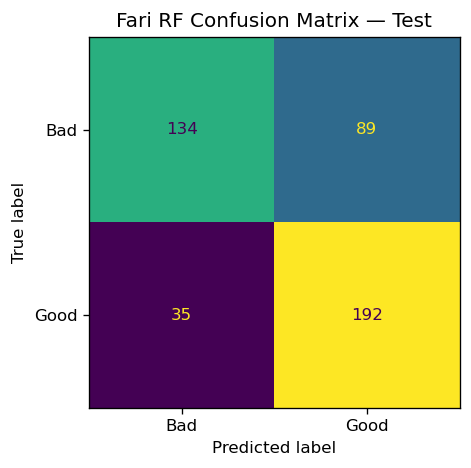

In [20]:
param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10, 20]}
rf_base = RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=1)
gs = GridSearchCV(rf_base, param_grid, cv=5, scoring='f1', n_jobs=-1)
gs.fit(Xf_tr, yf_tr)
fari_rf = gs.best_estimator_
print(f'Best hyperparameters: {gs.best_params_}')
print(f'CV best F1: {gs.best_score_:.4f}')

fari_rf_va_proba = fari_rf.predict_proba(Xf_va)[:, 1]
fari_rf_te_proba = fari_rf.predict_proba(Xf_te)[:, 1]

# val-tuned decision threshold — same protocol as the Week-2 RF benchmark and the MLP models here.
fari_rf_threshold, fari_rf_val_f1_tuned = tune_threshold(yf_va, fari_rf_va_proba)
print(f'Val-tuned decision threshold: {fari_rf_threshold:.2f}  (val F1 {fari_rf_val_f1_tuned:.4f} '
      f'vs {f1_score(yf_va, (fari_rf_va_proba >= 0.5).astype(int)):.4f} at default t=0.50)')

for X, y, proba, split_name in [(Xf_tr, yf_tr, fari_rf.predict_proba(Xf_tr)[:, 1], 'Train'),
                                 (Xf_va, yf_va, fari_rf_va_proba, 'Validation'),
                                 (Xf_te, yf_te, fari_rf_te_proba, 'Test')]:
    pred = (proba >= fari_rf_threshold).astype(int)
    print(f'\n-- {split_name} --')
    print(classification_report(y, pred, target_names=['Bad', 'Good'], digits=4))
    print(f'AUC-ROC: {roc_auc_score(y, proba):.4f}')

fari_rf_test_pred = (fari_rf_te_proba >= fari_rf_threshold).astype(int)
fari_rf_test_f1 = f1_score(yf_te, fari_rf_test_pred)
fari_rf_test_f1_default = f1_score(yf_te, (fari_rf_te_proba >= 0.5).astype(int))
print(f'\nTest F1 — val-tuned threshold (t={fari_rf_threshold:.2f}): {fari_rf_test_f1:.4f}  |  '
      f'default t=0.50: {fari_rf_test_f1_default:.4f}')

fig, ax = plt.subplots(1, 1, figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(yf_te, fari_rf_test_pred),
                       display_labels=['Bad', 'Good']).plot(ax=ax, colorbar=False)
ax.set_title('Fari RF Confusion Matrix — Test')
plt.tight_layout()
plt.savefig(IMG_DIR / 'fari_rf_confusion_matrix.png')
plt.show()


### 4.2 MLP on the Fari Task

Fari MLP trained for 28 epochs
Val-tuned decision threshold: 0.40  (val F1 0.7644 vs 0.7396 at default t=0.50)

-- Train --
              precision    recall  f1-score   support

         Bad     0.7920    0.6242    0.6981      1043
        Good     0.6933    0.8382    0.7589      1057

    accuracy                         0.7319      2100
   macro avg     0.7426    0.7312    0.7285      2100
weighted avg     0.7423    0.7319    0.7287      2100

AUC-ROC: 0.8252

-- Validation --
              precision    recall  f1-score   support

         Bad     0.8070    0.6161    0.6987       224
        Good     0.6918    0.8540    0.7644       226

    accuracy                         0.7356       450
   macro avg     0.7494    0.7350    0.7315       450
weighted avg     0.7491    0.7356    0.7317       450

AUC-ROC: 0.8095

-- Test --
              precision    recall  f1-score   support

         Bad     0.7874    0.6143    0.6902       223
        Good     0.6884    0.8370    0.7555       2

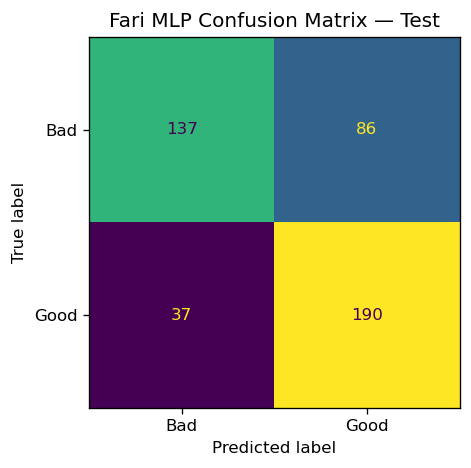

In [21]:
fari_mlp, fari_history, fari_n_epochs = run_config(
    5, (16, 8), 'relu', 0.3, 'adam', Xf_tr, yf_tr, Xf_va, yf_va, DEVICE, max_epochs=100, patience=10)
print(f'Fari MLP trained for {fari_n_epochs} epochs')

fari_mlp.to(DEVICE).eval()
with torch.no_grad():
    def predict_fari_proba(X):
        out = fari_mlp(torch.tensor(X, dtype=torch.float32, device=DEVICE))
        return torch.softmax(out, dim=1)[:, 1].cpu().numpy()

    fari_mlp_tr_proba = predict_fari_proba(Xf_tr)
    fari_mlp_va_proba = predict_fari_proba(Xf_va)
    fari_mlp_te_proba = predict_fari_proba(Xf_te)

# val-tuned decision threshold — same protocol as every other model in this notebook.
fari_mlp_threshold, fari_mlp_val_f1_tuned = tune_threshold(yf_va, fari_mlp_va_proba)
print(f'Val-tuned decision threshold: {fari_mlp_threshold:.2f}  (val F1 {fari_mlp_val_f1_tuned:.4f} '
      f'vs {f1_score(yf_va, (fari_mlp_va_proba >= 0.5).astype(int)):.4f} at default t=0.50)')

for y, proba, split_name in [(yf_tr, fari_mlp_tr_proba, 'Train'),
                              (yf_va, fari_mlp_va_proba, 'Validation'),
                              (yf_te, fari_mlp_te_proba, 'Test')]:
    pred = (proba >= fari_mlp_threshold).astype(int)
    print(f'\n-- {split_name} --')
    print(classification_report(y, pred, target_names=['Bad', 'Good'], digits=4))
    print(f'AUC-ROC: {roc_auc_score(y, proba):.4f}')

fari_mlp_test_pred = (fari_mlp_te_proba >= fari_mlp_threshold).astype(int)
fari_mlp_test_f1 = f1_score(yf_te, fari_mlp_test_pred)
fari_mlp_test_f1_default = f1_score(yf_te, (fari_mlp_te_proba >= 0.5).astype(int))
print(f'\nTest F1 — val-tuned threshold (t={fari_mlp_threshold:.2f}): {fari_mlp_test_f1:.4f}  |  '
      f'default t=0.50: {fari_mlp_test_f1_default:.4f}')

fig, ax = plt.subplots(1, 1, figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(yf_te, fari_mlp_test_pred),
                       display_labels=['Bad', 'Good']).plot(ax=ax, colorbar=False)
ax.set_title('Fari MLP Confusion Matrix — Test')
plt.tight_layout()
plt.savefig(IMG_DIR / 'fari_mlp_confusion_matrix.png')
plt.show()


**Generalisation check:** compare `fari_rf_test_f1` and `fari_mlp_test_f1` above against the Aido
Rover results — both pipelines (classical RF grid-search, MLP with class-weighted CE, both now
using the same val-tuned-threshold protocol) ran unmodified on a 5-D non-sensor, non-time-series
tabular task and produced usable classifiers, evidence that the methodology (not just the
Rover-specific feature engineering) transfers across domains. Both test F1s should sit close to the
`bayes_f1` ceiling printed in §4's data-generation cell — the label was deliberately drawn as a
*noisy* Bernoulli sample of the true probability (not the probability itself), so RF and MLP scoring
near that ceiling and near each other is the expected outcome of an already-near-optimal fit on
this task, not evidence that either model under-performed.


## 5. Model Ledger

Scope note: the plan ties this ledger to the Rover/platform latency Pareto frontier (W03 task list
names MLP and 1D-CNN specifically; the W07 Pareto model list and its per-platform constraints —
Aido Rover 100ms, Aido Humanoid 50ms — never include Fari). Fari (§4) is a one-off generalisation
check, not a recurring cross-model-comparison target, and has no plan-defined latency gate, so its
results stay in §4 (metrics, confusion matrices, latency, Bayes ceiling all reported there) and are
not appended here.

**Fold protocol:** every row's `f1_test` / `f1_test_std` is the **mean ± std F1 over the 7
canonical-split fold rotations** (fixed config, no per-fold re-tuning), per the project's
fold-evaluation protocol — RF's rotation was already run in `W02_RF_Benchmark.ipynb` §7.2 (carried
forward here); MLP's rotation is §2.6 above; 1D-CNN's rotation is §3.5 (the pooling head is selected in §3.2, the optimiser in §3.3, both
empirically -- pooling overriding the plan's original GAP-only default). `fold_0`..`fold_6`
store each model's individual per-fold tuned-F1 — all three models rotate over the identical fold
partition (`test=fold k`, same `rover_stratified_block_split.csv`), so these columns line up
fold-for-fold across rows, which lets a later paired per-fold comparison (Week-7 cross-model /
Pareto analysis) read the difference straight off this file without re-running any rotation.
`latency_ms` stays a single canonical-fold CPU measurement — latency is a function of architecture
and hardware, not of which rows happen to be in test, so it does not need to be averaged over folds.
Every row's operating point is a val-tuned decision threshold, re-tuned per rotation on that
rotation's own val fold.

In [2]:
ledger_path = DATA_DIR / 'model_ledger.csv'
FOLD_COLS = [f'fold_{k}' for k in range(7)]
AUC_FOLD_COLS = [f'auc_fold_{k}' for k in range(7)]

# carried forward from W02_RF_Benchmark.ipynb §7.2 (same fold_id convention: test=fold k, val=fold (k+1)%7)
rf_f1_tuned_7f = [0.7179, 0.7804, 0.7622, 0.6971, 0.8447, 0.7027, 0.7396]
rf_auc_7f = [0.9510, 0.9730, 0.9655, 0.9531, 0.9707, 0.9537, 0.9495]

rows = [
    {'week': 2, 'model': 'RandomForest', 'task': 'rover_anomaly', 'platform': 'Aido Rover',
     'split_protocol': 'block-stratified', 'fold_protocol': '7-fold (block rotation)',
     'latency_ms': 7.856, 'f1_test': round(float(np.mean(rf_f1_tuned_7f)), 4),
     'f1_test_std': round(float(np.std(rf_f1_tuned_7f)), 4),
     **dict(zip(FOLD_COLS, [round(v, 4) for v in rf_f1_tuned_7f])),
     'auc_test': round(float(np.mean(rf_auc_7f)), 4),
     'auc_test_std': round(float(np.std(rf_auc_7f)), 4),
     **dict(zip(AUC_FOLD_COLS, [round(v, 4) for v in rf_auc_7f])),
     'constraint_ms': CONSTRAINT_MS, 'verdict': 'PASS',
     'notes': 'carried forward from W02_RF_Benchmark.ipynb (Pipeline: scaler+PCA(19 components)+RF, '
              '7-fold block rotation, val-tuned threshold per rotation)'},
    {'week': 3, 'model': 'MLP', 'task': 'rover_anomaly', 'platform': 'Aido Rover',
     'split_protocol': 'block-stratified', 'fold_protocol': '7-fold (block rotation)',
     'latency_ms': round(mlp_single_ms, 4),
     'f1_test': round(mlp_f1_tuned_7f.mean(), 4), 'f1_test_std': round(mlp_f1_tuned_7f.std(), 4),
     **dict(zip(FOLD_COLS, [round(float(v), 4) for v in mlp_f1_tuned_7f])),
     'auc_test': round(mlp_auc_7f.mean(), 4), 'auc_test_std': round(mlp_auc_7f.std(), 4),
     **dict(zip(AUC_FOLD_COLS, [round(float(v), 4) for v in mlp_auc_7f])),
     'constraint_ms': CONSTRAINT_MS, 'verdict': mlp_verdict,
     'notes': f'40-D raw+FFT+physical input, activation={best_activation}, dropout={best_dropout}, '
              f'optimizer={best_opt}, 7-fold block rotation, val-tuned threshold per rotation '
              f'(canonical-fold snapshot: t={mlp_threshold:.2f}, F1={mlp_test_f1:.4f})'},
    {'week': 3, 'model': '1D-CNN', 'task': 'rover_anomaly', 'platform': 'Aido Rover',
     'split_protocol': 'block-stratified', 'fold_protocol': '7-fold (block rotation)',
     'latency_ms': round(cnn_single_ms, 4),
     'f1_test': round(cnn_f1_tuned_7f.mean(), 4), 'f1_test_std': round(cnn_f1_tuned_7f.std(), 4),
     **dict(zip(FOLD_COLS, [round(float(v), 4) for v in cnn_f1_tuned_7f])),
     'auc_test': round(cnn_auc_7f.mean(), 4), 'auc_test_std': round(cnn_auc_7f.std(), 4),
     **dict(zip(AUC_FOLD_COLS, [round(float(v), 4) for v in cnn_auc_7f])),
     'constraint_ms': CONSTRAINT_MS, 'verdict': cnn_verdict,
     'notes': f'50-step window tensor (per-channel standardized), 2x Conv1d(k=3)+{cnn_final_pool}-pool '
              f'(selected empirically in §3.2 over avg/max/concat, overriding the plan\'s GAP default), '
              f'optimizer={cnn_best_opt} (selected in §3.3 over Adam; §3.5 shows this trades stability '
              f'for a lower mean-val-loss result), 7-fold block rotation (§3.5), '
              f'val-tuned threshold per rotation (canonical-fold snapshot: t={cnn_threshold:.2f}, F1={cnn_test_f1:.4f})'},
]

ledger_df = pd.DataFrame(rows)
ledger_df.to_csv(ledger_path, index=False)
print(f'Ledger written to {ledger_path.resolve()}')
ledger_df


Ledger written to /home/lhy/ingen_ml/hongyu-ingen-ml-analyst/data/model_ledger.csv


,week,model,task,platform,split_protocol,fold_protocol,latency_ms,f1_test,f1_test_std,fold_0,...,auc_fold_0,auc_fold_1,auc_fold_2,auc_fold_3,auc_fold_4,auc_fold_5,auc_fold_6,constraint_ms,verdict,notes
0,2,RandomForest,rover_anomaly,Aido Rover,block-stratified,7-fold (block rotation),7.8560,0.7492,0.0481,0.7179,...,0.9510,0.9730,0.9655,0.9531,0.9707,0.9537,0.9495,100.0,PASS,carried forward from W02_RF_Benchmark.ipynb (P...
1,3,MLP,rover_anomaly,Aido Rover,block-stratified,7-fold (block rotation),0.1351,0.7936,0.0472,0.7770,...,0.9938,0.9776,0.9630,0.9734,0.9884,0.9887,0.9653,100.0,PASS,"40-D raw+FFT+physical input, activation=relu, ..."
2,3,1D-CNN,rover_anomaly,Aido Rover,block-stratified,7-fold (block rotation),0.1516,0.7307,0.1147,0.7254,...,0.9566,0.9609,0.9165,0.9866,0.9778,0.9813,0.9737,100.0,PASS,50-step window tensor (per-channel standardize...
